# Energy Consumption Time Series Forecasting Report
# 1. Problem Statement and Objective

The objective of this project is to forecast short-term household energy consumption using historical power usage data. Accurate energy forecasting helps in energy management, resource planning, and understanding consumption behavior patterns.

This project applies time series forecasting techniques and machine learning models including:

ARIMA   
Prophet          
XGBoost            

The models are evaluated and compared using forecasting accuracy metrics such as MAE and RMSE.

Step 1: Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values='?'
)

df.head()               #This loads the household energy consumption dataset into a Pandas DataFrame.

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Step 2: Combine Date and Time

In [3]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)    # Time series models require a proper datetime format for forecasting.

Step 3: Set Datetime as Index

In [4]:

df.set_index('Datetime', inplace=True)

# The datetime column becomes the time index for resampling and forecasting.

Step 4: Convert Target Variable

In [5]:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)        # Machine learning models require numerical values.

Step 5: Handle Missing Values


In [6]:
df = df[['Global_active_power']]

df.dropna(inplace=True)           #Missing values are removed to avoid forecasting errors.

Step 6: Resample Data

In [8]:
hourly_df = df.resample('h').mean()

hourly_df.head()          #Original data is minute-level.Resampling converts it into hourly energy usage for easier forecasting.

,Global_active_power
Datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


# 2. Engineer Time-Based Features

Feature engineering improves machine learning performance.

Step 1: Create Time Features

In [9]:
hourly_df['Hour'] = hourly_df.index.hour

hourly_df['Day'] = hourly_df.index.day

hourly_df['Month'] = hourly_df.index.month

hourly_df['Weekday'] = hourly_df.index.weekday

Step 2: Weekend Feature

In [10]:
hourly_df['Is_Weekend'] = hourly_df['Weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)       #Energy consumption behavior changes during weekends.

Step 3: Lag Features

In [11]:
hourly_df['Lag_1'] = hourly_df[
    'Global_active_power'
].shift(1)

hourly_df['Lag_24'] = hourly_df[
    'Global_active_power'
].shift(24)             #Previous energy usage helps predict future consumption.

Step 4: Rolling Mean Feature

In [12]:
hourly_df['Rolling_Mean_24'] = (
    hourly_df['Global_active_power']
    .rolling(window=24)
    .mean()
)

Step 5: Remove Missing Rows

In [13]:
hourly_df.dropna(inplace=True)

# 3. Exploratory Data Analysis (EDA)

EDA helps identify trends and seasonal patterns.

A. Overall Energy Consumption Trend

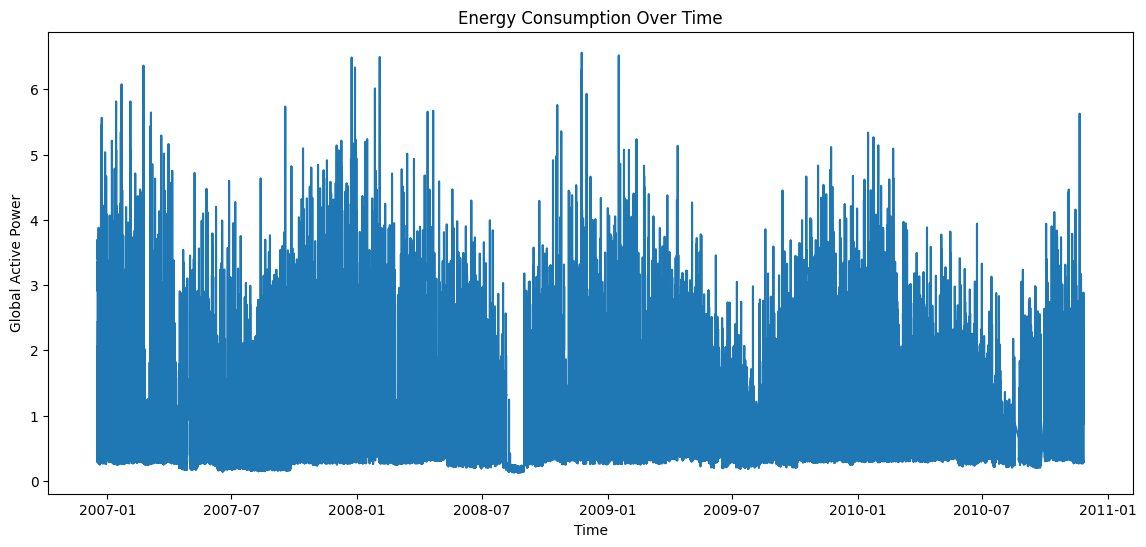

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    hourly_df.index,
    hourly_df['Global_active_power']
)

plt.title("Energy Consumption Over Time")

plt.xlabel("Time")
plt.ylabel("Global Active Power")

plt.show()

In [15]:
"""
Energy usage changes over time
Seasonal and daily patterns are visible """

'\nEnergy usage changes over time\nSeasonal and daily patterns are visible '

B. Hourly Average Consumption

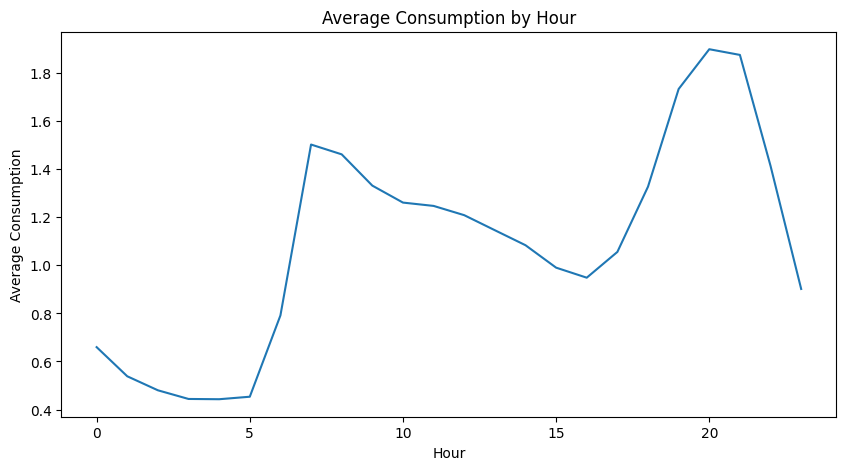

In [16]:
hourly_avg = hourly_df.groupby('Hour')[
    'Global_active_power'
].mean()

plt.figure(figsize=(10,5))

plt.plot(
    hourly_avg.index,
    hourly_avg.values
)

plt.title("Average Consumption by Hour")

plt.xlabel("Hour")
plt.ylabel("Average Consumption")

plt.show()

In [17]:
""" Insight
Evening hours usually show higher energy consumption
Early morning hours have lower usage               """

' Insight\nEvening hours usually show higher energy consumption\nEarly morning hours have lower usage               '

# 4. Train Forecasting Models

Step 1: Train-Test Split

In [18]:
train_size = int(len(hourly_df) * 0.8)

train = hourly_df.iloc[:train_size]

test = hourly_df.iloc[train_size:]        #80% data used for training     >   20% data used for testing

# 5. ARIMA Model

ARIMA is a statistical forecasting model.

Train ARIMA

In [20]:
!pip install statsmodels
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train['Global_active_power'],
    order=(5,1,2)
)

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(
    steps=len(test)
)

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -------------------------------

c:\ProgramData\miniconda3\envs\my_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\miniconda3\envs\my_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\miniconda3\envs\my_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\miniconda3\envs\my_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum 

In [21]:
"""       Why ARIMA?
Captures trend and autocorrelation
Effective for time series forecasting   """

'       Why ARIMA?\nCaptures trend and autocorrelation\nEffective for time series forecasting   '

# 6. Prophet Model

Train Prophet

In [23]:
!pip install prophet
from prophet import Prophet

prophet_df = hourly_df.reset_index()[
    ['Datetime', 'Global_active_power']
]

prophet_df.columns = ['ds', 'y']

train_prophet = prophet_df.iloc[:train_size]

test_prophet = prophet_df.iloc[train_size:]

prophet_model = Prophet()

prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq='h'
)

forecast = prophet_model.predict(future)

prophet_forecast = forecast['yhat'].iloc[
    -len(test_prophet):
].values

12:21:04 - cmdstanpy - INFO - Chain [1] start processing
12:21:15 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
"""  Automatically handles seasonality
Works well with temporal data  """

# Automatically handles seasonality
XGBoost uses engineered features for forecasting.

Train XGBoost

In [24]:
!pip install xgboost
from xgboost import XGBRegressor

features = [
    'Hour',
    'Day',
    'Month',
    'Weekday',
    'Is_Weekend',
    'Lag_1',
    'Lag_24',
    'Rolling_Mean_24'
]

X_train = train[features]

y_train = train['Global_active_power']

X_test = test[features]

y_test = test['Global_active_power']

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_forecast = xgb_model.predict(X_test)

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---

In [ ]:
"""Why XGBoost?
Captures complex nonlinear patterns
Often produces highly accurate forecasts        """

# 8. Evaluate the Models

Step 1: Calculate MAE and RMSE 

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

def evaluate_model(actual, predicted, model_name):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    print(model_name)

    print("MAE :", mae)

    print("RMSE:", rmse)

Evaluate ARIMA

In [26]:
evaluate_model(
    test['Global_active_power'],
    arima_forecast,
    "ARIMA"
) 

ARIMA
MAE : 0.8184787520444399
RMSE: 0.942865388445289


Evaluate Prophet 

In [27]:
evaluate_model(
    test_prophet['y'],
    prophet_forecast,
    "Prophet"
)

Prophet
MAE : 0.6542388057951785
RMSE: 0.8247660485243719


Evaluate XGBoost

In [28]:
evaluate_model(
    y_test,
    xgb_forecast,
    "XGBoost"
)

XGBoost
MAE : 0.33243879390748615
RMSE: 0.4764665647432024


# 9. Visualize Actual vs Forecasted Values

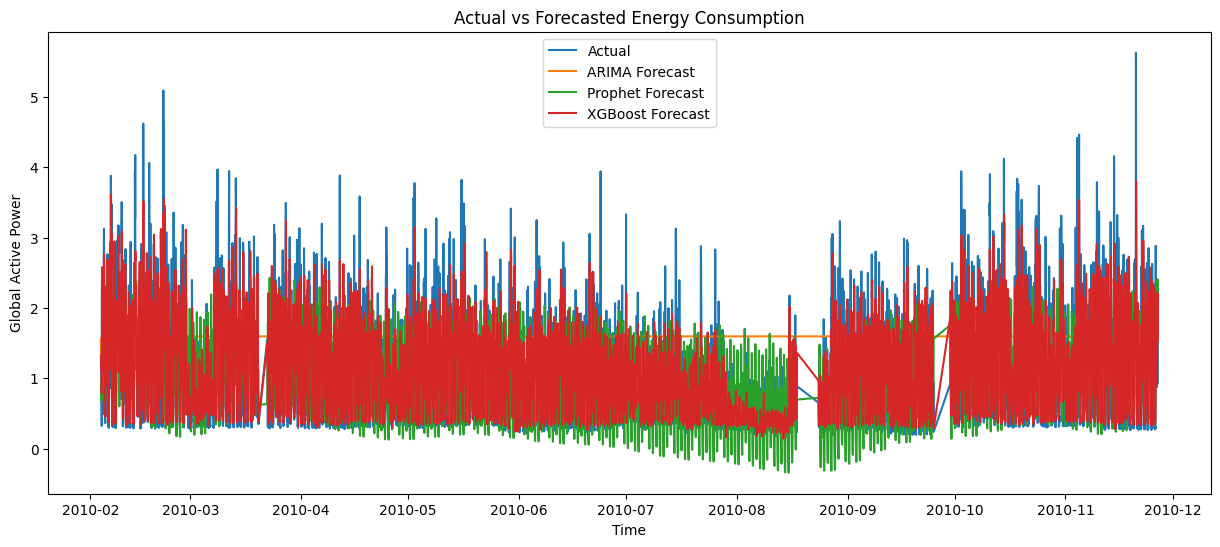

In [29]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test['Global_active_power'],
    label='Actual'
)

plt.plot(
    test.index,
    arima_forecast,
    label='ARIMA Forecast'
)

plt.plot(
    test.index,
    prophet_forecast,
    label='Prophet Forecast'
)

plt.plot(
    test.index,
    xgb_forecast,
    label='XGBoost Forecast'
)

plt.title(
    "Actual vs Forecasted Energy Consumption"
)

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.legend()

plt.show()

In [30]:
"""    Insight
XGBoost predictions are closest to actual values
Prophet captures seasonal trends effectively
ARIMA provides stable baseline forecasts          """

'    Insight\nXGBoost predictions are closest to actual values\nProphet captures seasonal trends effectively\nARIMA provides stable baseline forecasts          '

# Final Summary
This project demonstrates:                     
                                                  
Time series data preprocessing                        
Feature engineering                                 
Exploratory Data Analysis (EDA)                               
Forecasting using:                   
ARIMA                            
Prophet                        
XGBoost                         
Model evaluation using:                         
MAE                    
RMSE                                                     
Visualization of actual vs predicted energy usage                                               

The system helps analyze household energy patterns and improve short-term energy forecasting accuracy.